# Aula 12 — Big Data: Hadoop, Spark, Processamento Distribuído e Pipelines
**Ciência de Dados · Univassouras · Prof. Mesc. Diego Ramos Inácio**

---

> **Conexão com a Aula 11:** aprendemos a construir pipelines de ML com scikit-learn, utilizando GridSearchCV e algoritmos como Random Forest e SVM.
> Agora damos um salto de escala: e quando os dados **não cabem na memória** de um único computador?
> Essa é a fronteira do Big Data — e o Apache Spark é a ferramenta que a indústria usa para cruzá-la.

| # | Conteúdo |
|---|----------|
| 0 | Configuração do ambiente |
| 1 | **Exemplo 1** — MapReduce: do conceito à prática com Python |
| 2 | **Exemplo 2** — PySpark DataFrames: análise de logs de e-commerce |
| 3 | **Exemplo 3** — PySpark MLlib: pipeline de ML escalável |
| 4 | **Exemplo 4** — Particionamento, cache e DAG: entendendo a execução |
| 5 | **Exercício** — sua vez! |

> **Instalação necessária:** `pip install pyspark`  
> PySpark roda em modo local (sem cluster) — ideal para aprender e prototipar.
> **Requisito:** Java 8 ou superior instalado no sistema.

> **Dica:** execute cada célula com `Shift + Enter`.

## 0 · Configuração do Ambiente

### Por que o PySpark?

O **Apache Spark** é o framework de processamento distribuído mais usado no mundo. Com `pyspark`, você pode rodar Spark **localmente** no seu computador em modo de simulação — sem precisar de um cluster real.

> **Modo local:** `SparkSession.builder.master("local[*]")` usa todos os núcleos da sua CPU como se fossem workers separados. É ideal para aprender, desenvolver e testar código que depois vai rodar em clusters reais.

---

### Passo 1 — Instalar o Java (obrigatório)

O Spark é escrito em Scala/JVM e **exige o Java instalado** no Windows antes de qualquer coisa.

**Instalação no Windows (passo a passo):**

1. Acesse **https://adoptium.net** no navegador.
2. Clique em **Latest LTS release** e baixe o instalador `.msi` para **Windows x64** — recomendamos a versão **Temurin 11 LTS**.
3. Execute o arquivo `.msi` como **Administrador** (botão direito > Executar como administrador).
4. Durante a instalação, na tela de seleção de componentes, certifique-se de marcar:
   - **Set JAVA_HOME variable** — cria a variável de ambiente necessária para o Spark encontrar o Java.
   - **Add to PATH** — permite usar o comando `java` em qualquer terminal.
5. Conclua a instalação normalmente.
6. **Reinicie o computador** para que as variáveis de ambiente sejam aplicadas.
7. Abra o **Prompt de Comando** (cmd) ou o **PowerShell** e verifique:

```cmd
java -version
```

Saída esperada (o número exato da versão pode variar):

```
openjdk version "11.0.22" 2024-01-16
OpenJDK Runtime Environment Temurin-11.0.22+7 (build 11.0.22+7)
OpenJDK 64-Bit Server VM Temurin-11.0.22+7 (build 11.0.22+7, mixed mode)
```

> Se o comando não for reconhecido mesmo após reiniciar, verifique manualmente:
> Painel de Controle > Sistema > Variaveis de Ambiente > confirme que `JAVA_HOME` aponta para a pasta de instalacao do Java (ex.: `C:\Program Files\Eclipse Adoptium\jdk-11...`).

---

### Passo 2 — Instalar o PySpark

Com o Java instalado e verificado, abra o **Prompt de Comando** (cmd) ou o **Anaconda Prompt** e execute:

```bash
pip install pyspark
```

Apos a instalacao, **reinicie o kernel do Jupyter** (menu Kernel > Restart) antes de executar as celulas abaixo.

In [1]:
# !pip install pyspark --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import warnings
import os, sys
warnings.filterwarnings('ignore')

# Garante que o PySpark use o mesmo Python do Jupyter (essencial no Windows)
os.environ['PYSPARK_PYTHON'] = sys.executable
os.environ['PYSPARK_DRIVER_PYTHON'] = sys.executable

# PySpark
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import (
    StructType, StructField, StringType,
    IntegerType, FloatType, DoubleType
)

# PySpark MLlib
from pyspark.ml import Pipeline as SparkPipeline
from pyspark.ml.feature import (
    VectorAssembler, StandardScaler as SparkScaler,
    StringIndexer
)
from pyspark.ml.classification import (
    LogisticRegression as SparkLR,
    RandomForestClassifier as SparkRF
)
from pyspark.ml.evaluation import (
    BinaryClassificationEvaluator,
    MulticlassClassificationEvaluator
)
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

np.random.seed(42)
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})

# ── Criar SparkSession em modo local ──────────────────────────────────────────
spark = (
    SparkSession.builder
    .appName("Aula12_BigData")
    .master("local[*]")             # usa todos os núcleos da CPU
    .config("spark.driver.memory", "2g")
    .config("spark.sql.shuffle.partitions", "4")  # reduz para datasets pequenos
    .config("spark.ui.showConsoleProgress", "false")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")

print('Ambiente PySpark pronto!')
print(f'Spark versão: {spark.version}')
print(f'Núcleos disponíveis: {spark.sparkContext.defaultParallelism}')
print(f'Python worker: {sys.executable}')

Ambiente PySpark pronto!
Spark versão: 4.1.2
Núcleos disponíveis: 12
Python worker: C:\Users\Diego\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe


---
## 1 · Exemplo 1 — MapReduce: do Conceito à Prática
### Problema: contar frequência de palavras em um corpus de notícias

**O que é MapReduce?** É um paradigma de programação para processar grandes volumes de dados em paralelo. Divide o trabalho em duas fases:

```
FASE MAP (mapeamento — cada worker processa sua partição)
─────────────────────────────────────────────────────────
Partição 1: "dados são importantes" → [(dados,1), (são,1), (importantes,1)]
Partição 2: "dados distribuídos"    → [(dados,1), (distribuídos,1)]
Partição 3: "spark processa dados"  → [(spark,1), (processa,1), (dados,1)]

FASE SHUFFLE (agrupamento por chave — redistribui os pares)
─────────────────────────────────────────────────────────────
dados       → [1, 1, 1]   (todas as ocorrências juntas)
são         → [1]
importantes → [1]
distribuídos → [1]
spark       → [1]
processa    → [1]

FASE REDUCE (redução — agrega os valores de cada chave)
─────────────────────────────────────────────────────────
dados        → 3
são          → 1
importantes  → 1
distribuídos → 1
spark        → 1
processa     → 1
```

**A grande vantagem:** cada fase pode rodar em paralelo em centenas de máquinas. Um corpus de 1 TB é dividido em milhares de partições de 128 MB (tamanho padrão de bloco HDFS), e cada uma é processada por um worker diferente simultaneamente.

### Por que o MapReduce revolucionou o processamento de dados?

Antes do MapReduce (artigo do Google, 2004), processar terabytes de dados exigia código complexo e específico para cada problema. O MapReduce padronizou o padrão: **qualquer problema que possa ser expresso como map + reduce pode ser paralelizado automaticamente**.

O Hadoop implementou o MapReduce como framework open-source em 2006. O Spark surgiu em 2010 como alternativa mais rápida (processa em memória, não em disco).

| Característica | Hadoop MapReduce | Apache Spark |
|---|---|---|
| Armazenamento intermediário | Disco (HDFS) | Memória RAM |
| Velocidade relativa | 1× (referência) | 10–100× mais rápido |
| API | Java verboso | Python/Scala/R intuitivo |
| ML nativo | Não (usa Mahout) | Sim (MLlib integrado) |
| Streaming | Não | Sim (Spark Streaming) |

In [2]:
# ── Corpus sintético de notícias de tecnologia ─────────────────────────────────
noticias = [
    "Apache Spark revolucionou o processamento distribuído de dados em grande escala",
    "Big Data requer infraestrutura distribuída com Hadoop e clusters de alta performance",
    "Machine learning em dados distribuídos com PySpark MLlib e pipelines escaláveis",
    "Hadoop HDFS armazena dados em blocos distribuídos por múltiplos servidores",
    "Spark processa dados em memória sendo muito mais rápido que o Hadoop MapReduce",
    "Pipelines de dados modernos combinam Kafka Spark e armazenamento em nuvem",
    "Processamento em tempo real com Spark Streaming e Apache Kafka para dados de IoT",
    "DataFrames Spark oferecem API similar ao pandas mas para dados distribuídos",
    "Clusters Spark com YARN ou Kubernetes gerenciam recursos de processamento distribuído",
    "Dados de Big Data crescem exponencialmente exigindo soluções escaláveis de armazenamento",
    "Spark SQL permite consultas SQL em dados distribuídos com otimização automática",
    "MLlib do Spark implementa algoritmos de machine learning para dados em grande escala",
    "Processamento distribuído paralelo reduz tempo de análise de terabytes para minutos",
    "Apache Kafka integra com Spark para pipelines de streaming de dados em tempo real",
    "Particionamento inteligente dos dados melhora a performance do processamento distribuído",
]

print(f'Corpus: {len(noticias)} notícias')
print(f'Total de palavras (aproximado): {sum(len(n.split()) for n in noticias)}')
print('\nExemplo de notícia:')
print(f'  "{noticias[0]}"')

Corpus: 15 notícias
Total de palavras (aproximado): 174

Exemplo de notícia:
  "Apache Spark revolucionou o processamento distribuído de dados em grande escala"


In [3]:
# ── Implementação do MapReduce com Python puro ─────────────────────────────────
import re
from functools import reduce
from collections import defaultdict

# Palavras de parada (stop words)
STOP_WORDS = {'de', 'em', 'com', 'e', 'o', 'a', 'os', 'as', 'do', 'da', 'dos',
               'das', 'no', 'na', 'por', 'para', 'que', 'um', 'uma', 'ser',
               'ao', 'mais', 'mas', 'ou', 'se', 'foi'}

# Usar isalpha() evita regex com chars acentuados, que causa erro de encoding
# nos workers do PySpark no Windows
def limpar(texto):
    return ''.join(c if (c.isalpha() or c.isspace()) else ' ' for c in texto.lower())

# ── FASE MAP: cada "partição" (notícia) gera pares (palavra, 1)
def mapper(texto):
    palavras = limpar(texto).split()
    return [(p, 1) for p in palavras if p not in STOP_WORDS and len(p) > 2]

# Aplicar map em todas as notícias (em paralelo em Spark, sequencial aqui)
t0 = time.time()
pares_mapeados = []
for i, noticia in enumerate(noticias):
    pares = mapper(noticia)
    pares_mapeados.extend(pares)
    print(f'  Partição {i+1:2d}: {len(pares):2d} pares gerados → {pares[:3]}...')

print(f'\nFASE MAP: {len(pares_mapeados)} pares (palavra, 1) gerados')

# ── FASE SHUFFLE: agrupar pares pela chave (palavra)
grupos = defaultdict(list)
for palavra, count in pares_mapeados:
    grupos[palavra].append(count)

print(f'FASE SHUFFLE: {len(grupos)} palavras únicas agrupadas')

# ── FASE REDUCE: somar as contagens de cada palavra
def reducer(acc, val):
    return acc + val

contagem = {palavra: reduce(reducer, lista) for palavra, lista in grupos.items()}
resultado = sorted(contagem.items(), key=lambda x: x[1], reverse=True)

tempo_mr = time.time() - t0

print(f'FASE REDUCE: contagem final calculada')
print(f'\nTop 15 palavras mais frequentes:')
for i, (palavra, freq) in enumerate(resultado[:15], 1):
    barra = '█' * freq
    print(f'  {i:2d}. {palavra:20s} {freq:3d} {barra}')
print(f'\nTempo total (MapReduce Python): {tempo_mr*1000:.2f} ms')

  Partição  1:  8 pares gerados → [('apache', 1), ('spark', 1), ('revolucionou', 1)]...
  Partição  2:  9 pares gerados → [('big', 1), ('data', 1), ('requer', 1)]...
  Partição  3:  8 pares gerados → [('machine', 1), ('learning', 1), ('dados', 1)]...
  Partição  4:  8 pares gerados → [('hadoop', 1), ('hdfs', 1), ('armazena', 1)]...
  Partição  5:  9 pares gerados → [('spark', 1), ('processa', 1), ('dados', 1)]...
  Partição  6:  8 pares gerados → [('pipelines', 1), ('dados', 1), ('modernos', 1)]...
  Partição  7:  9 pares gerados → [('processamento', 1), ('tempo', 1), ('real', 1)]...
  Partição  8:  8 pares gerados → [('dataframes', 1), ('spark', 1), ('oferecem', 1)]...
  Partição  9:  8 pares gerados → [('clusters', 1), ('spark', 1), ('yarn', 1)]...
  Partição 10:  9 pares gerados → [('dados', 1), ('big', 1), ('data', 1)]...
  Partição 11:  9 pares gerados → [('spark', 1), ('sql', 1), ('permite', 1)]...
  Partição 12:  9 pares gerados → [('mllib', 1), ('spark', 1), ('implementa', 1)].

In [4]:
# ── O mesmo WordCount com PySpark DataFrame API ─────────────────────────────────
# Nota: RDD com Python UDFs (flatMap/mapper) exige processos worker separados,
# o que falha no Python da Microsoft Store no Windows. A DataFrame API resolve isso:
# todas as operações rodam no JVM sem precisar spawnar processos Python externos.
t1 = time.time()

# Criar Spark DataFrame com as notícias
df_noticias = spark.createDataFrame([(n,) for n in noticias], ['texto'])

# Pipeline MapReduce com funções nativas do Spark (100% JVM, sem worker Python)
#
#   MAP:    regexp_replace + split + explode  ≡  flatMap
#           cada texto → palavras individuais limpas
#
#   REDUCE: groupBy + count  ≡  reduceByKey
#           agrupa e conta cada palavra
#
contagem_spark = (
    df_noticias
    .select(
        F.explode(
            F.split(
                F.regexp_replace(F.lower(F.col('texto')), r'[^\p{L}\s]', ' '),
                r'\s+'
            )
        ).alias('palavra')
    )
    .where(F.length('palavra') > 2)
    .where(~F.col('palavra').isin(list(STOP_WORDS)))
    .groupBy('palavra')
    .agg(F.count('*').alias('freq'))
    .orderBy(F.col('freq').desc())
    .limit(15)
)

# collect() aqui só transfere o resultado JVM → Python driver (sem worker)
top15_spark = [(row['palavra'], row['freq']) for row in contagem_spark.collect()]
tempo_spark = time.time() - t1

print('Top 15 palavras (PySpark):')
for i, (palavra, freq) in enumerate(top15_spark, 1):
    print(f'  {i:2d}. {palavra:20s} {freq}')

print(f'\nTempo PySpark: {tempo_spark*1000:.2f} ms')
print(f'Partições: {df_noticias.rdd.getNumPartitions()}')
print('\n→ Em dados reais (TB), o Spark distribui cada partição para um worker diferente,')
print('  processando tudo em paralelo e reduzindo o tempo de horas para minutos.')

Top 15 palavras (PySpark):
   1. dados                12
   2. spark                9
   3. processamento        5
   4. distribuído          4
   5. distribuídos         4
   6. apache               3
   7. hadoop               3
   8. pipelines            3
   9. kafka                3
  10. tempo                3
  11. grande               2
  12. escala               2
  13. clusters             2
  14. big                  2
  15. data                 2

Tempo PySpark: 13595.88 ms
Partições: 12

→ Em dados reais (TB), o Spark distribui cada partição para um worker diferente,
  processando tudo em paralelo e reduzindo o tempo de horas para minutos.


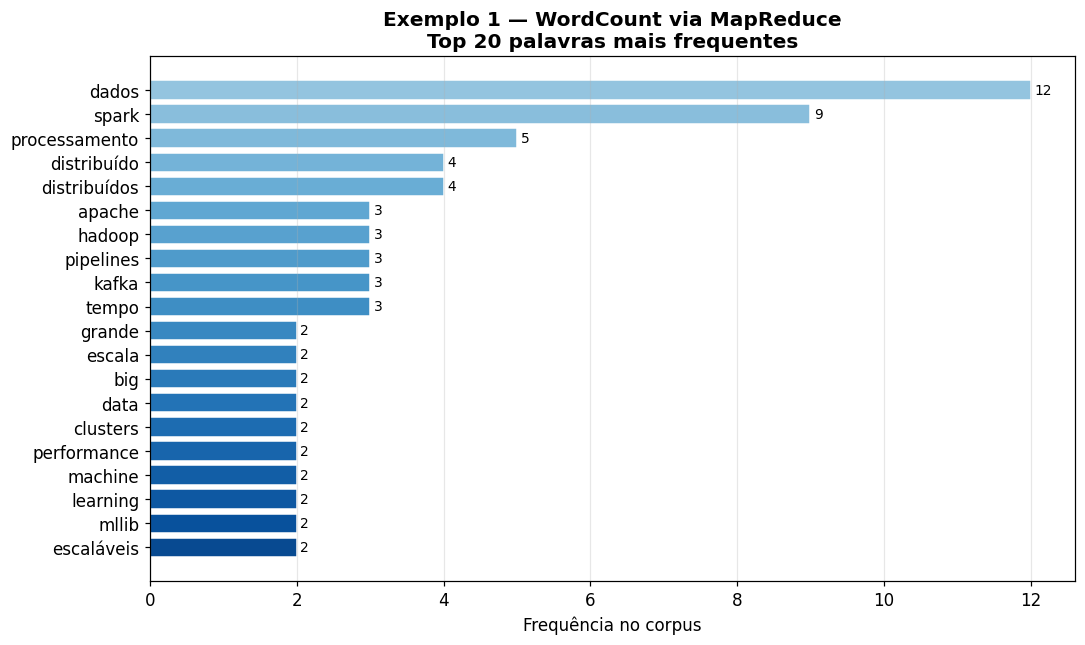

Observação: palavras como "dados", "distribuído" e "spark" são centrais
no corpus — exatamente o que o WordCount revela automaticamente.


In [5]:
# ── Visualização: frequência das palavras ──────────────────────────────────────
top20 = resultado[:20]
palavras_plot = [p for p, _ in top20]
freqs_plot    = [f for _, f in top20]

cores_plot = plt.cm.Blues(np.linspace(0.4, 0.9, len(top20)))[::-1]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(palavras_plot[::-1], freqs_plot[::-1], color=cores_plot, edgecolor='white')

for bar, freq in zip(bars, freqs_plot[::-1]):
    ax.text(freq + 0.05, bar.get_y() + bar.get_height()/2,
            str(freq), va='center', fontsize=9)

ax.set_xlabel('Frequência no corpus')
ax.set_title('Exemplo 1 — WordCount via MapReduce\nTop 20 palavras mais frequentes', fontweight='bold')
ax.grid(axis='x', alpha=.3)
plt.tight_layout()
plt.show()

print('Observação: palavras como "dados", "distribuído" e "spark" são centrais')
print('no corpus — exatamente o que o WordCount revela automaticamente.')

---
## 2 · Exemplo 2 — PySpark DataFrames: Análise de E-Commerce
### Problema: analisar padrões de vendas em uma plataforma de e-commerce

**Variáveis:** pedido_id, cliente_id, categoria, produto, valor, desconto, estado, data_pedido, entregue

---

### RDD vs DataFrame: qual usar?

O Spark tem duas APIs principais:

| Característica | RDD | DataFrame |
|---|---|---|
| Nível de abstração | Baixo (operações funcionais) | Alto (SQL-like, otimizado) |
| Otimização automática | Não | Sim (Catalyst Optimizer) |
| Tipagem | Sem schema | Com schema definido |
| API Python | Pythônica mas verbosa | Similar ao pandas |
| Performance | Depende do código | Automaticamente otimizado |
| Quando usar | Dados não estruturados, lógica complexa | Dados tabulares — use SEMPRE que possível |

> **Regra prática:** use sempre **DataFrame** (ou Spark SQL) para dados tabulares. O **Catalyst Optimizer** (o otimizador de queries do Spark) pode reordenar, combinar e otimizar operações automaticamente — algo impossível com RDD puro.

### O que é o Catalyst Optimizer?

Quando você escreve uma query Spark SQL ou operações em DataFrame, o Spark **não a executa imediatamente**. Em vez disso:

```
1. Plano lógico não resolvido  → parser analisa o código
2. Plano lógico resolvido      → resolve nomes de colunas, tipos
3. Plano lógico otimizado      → Catalyst aplica regras de otimização
                                  (pushdown de filtros, eliminação de colunas, etc.)
4. Plano físico                → escolhe o melhor algoritmo de join, sort, etc.
5. Geração de código           → gera bytecode JVM otimizado para execução
```

Isso significa que a **ordem em que você escreve as operações não precisa ser a ordem ótima de execução** — o Spark descobre sozinho a ordem mais eficiente.

In [6]:
# ── Dados sintéticos de e-commerce ────────────────────────────────────────────
np.random.seed(42)
n2 = 5000

categorias = ['Eletrônicos', 'Moda', 'Casa', 'Esportes', 'Livros', 'Beleza']
estados    = ['SP', 'RJ', 'MG', 'RS', 'PR', 'BA', 'PE', 'CE']

# Pesos diferentes por categoria (Eletrônicos são mais vendidos)
pesos_cat = [0.30, 0.25, 0.18, 0.12, 0.08, 0.07]
cat_escolhidas = np.random.choice(categorias, n2, p=pesos_cat)

# Valores médios por categoria
valores_medios = {'Eletrônicos': 800, 'Moda': 150, 'Casa': 200,
                  'Esportes': 250, 'Livros': 60, 'Beleza': 90}
valores = np.array([
    max(10, np.random.normal(valores_medios[c], valores_medios[c]*0.4))
    for c in cat_escolhidas
])

desconto = np.random.choice([0, 5, 10, 15, 20, 30], n2, p=[0.4, 0.15, 0.2, 0.1, 0.1, 0.05])
estado   = np.random.choice(estados, n2, p=[0.3, 0.2, 0.15, 0.1, 0.1, 0.07, 0.05, 0.03])

# Data do pedido (últimos 365 dias)
dias_atras = np.random.randint(0, 365, n2)
from datetime import date, timedelta
datas = [(date(2025, 5, 25) - timedelta(days=int(d))).isoformat() for d in dias_atras]

entregue = np.random.choice([1, 0], n2, p=[0.92, 0.08])

# Criar pandas DataFrame
df_ecom_pd = pd.DataFrame({
    'pedido_id':   range(1, n2 + 1),
    'cliente_id':  np.random.randint(1000, 9999, n2),
    'categoria':   cat_escolhidas,
    'valor_bruto': valores.round(2),
    'desconto_pct': desconto,
    'valor_liquido': (valores * (1 - desconto/100)).round(2),
    'estado':      estado,
    'data_pedido': datas,
    'entregue':    entregue
})

# Converter para Spark DataFrame
df_ecom = spark.createDataFrame(df_ecom_pd)
df_ecom.cache()  # manter em memória para consultas rápidas

print(f'Spark DataFrame criado: {df_ecom.count():,} pedidos')
print(f'Partições: {df_ecom.rdd.getNumPartitions()}')
print('\nSchema do DataFrame:')
df_ecom.printSchema()
print('\nAmostra:')
df_ecom.show(5, truncate=False)

Spark DataFrame criado: 5,000 pedidos
Partições: 12

Schema do DataFrame:
root
 |-- pedido_id: long (nullable = true)
 |-- cliente_id: long (nullable = true)
 |-- categoria: string (nullable = true)
 |-- valor_bruto: double (nullable = true)
 |-- desconto_pct: long (nullable = true)
 |-- valor_liquido: double (nullable = true)
 |-- estado: string (nullable = true)
 |-- data_pedido: string (nullable = true)
 |-- entregue: long (nullable = true)


Amostra:
+---------+----------+-----------+-----------+------------+-------------+------+-----------+--------+
|pedido_id|cliente_id|categoria  |valor_bruto|desconto_pct|valor_liquido|estado|data_pedido|entregue|
+---------+----------+-----------+-----------+------------+-------------+------+-----------+--------+
|1        |6049      |Moda       |114.18     |0           |114.18       |PE    |2025-04-03 |1       |
|2        |6557      |Beleza     |10.0       |0           |10.0         |PR    |2024-10-09 |1       |
|3        |5432      |Esportes 

In [7]:
# ── Operações fundamentais do Spark DataFrame ──────────────────────────────────

# 1. Estatísticas descritivas
print('=== Estatísticas descritivas ===')
df_ecom.select('valor_bruto', 'valor_liquido', 'desconto_pct').describe().show()

# 2. Faturamento por categoria (groupBy + agg)
print('=== Faturamento por categoria ===')
faturamento_cat = (
    df_ecom
    .groupBy('categoria')
    .agg(
        F.count('pedido_id').alias('n_pedidos'),
        F.round(F.sum('valor_liquido'), 2).alias('faturamento_total'),
        F.round(F.avg('valor_liquido'), 2).alias('ticket_medio'),
        F.round(F.avg('desconto_pct'), 1).alias('desconto_medio_pct')
    )
    .orderBy('faturamento_total', ascending=False)
)
faturamento_cat.show()

# 3. Taxa de entrega por estado
print('=== Taxa de entrega por estado ===')
(
    df_ecom
    .groupBy('estado')
    .agg(
        F.count('pedido_id').alias('pedidos'),
        F.round(F.avg('entregue') * 100, 1).alias('taxa_entrega_pct')
    )
    .orderBy('taxa_entrega_pct')
    .show()
)

=== Estatísticas descritivas ===
+-------+------------------+-----------------+-----------------+
|summary|       valor_bruto|    valor_liquido|     desconto_pct|
+-------+------------------+-----------------+-----------------+
|  count|              5000|             5000|             5000|
|   mean| 360.6399639999999|332.2135180000001|            7.805|
| stddev|355.43940885258036|330.2451697007328|8.554625142124253|
|    min|              10.0|              7.0|                0|
|    max|           1808.66|          1797.66|               30|
+-------+------------------+-----------------+-----------------+

=== Faturamento por categoria ===
+-----------+---------+-----------------+------------+------------------+
|  categoria|n_pedidos|faturamento_total|ticket_medio|desconto_medio_pct|
+-----------+---------+-----------------+------------+------------------+
|Eletrônicos|     1531|       1141736.33|      745.75|               7.9|
|       Casa|      919|        169839.68|      184.

In [8]:
# ── Spark SQL: consultas SQL em DataFrames ─────────────────────────────────────

# Registrar o DataFrame como view temporária SQL
df_ecom.createOrReplaceTempView('pedidos')

# Query 1: Top 5 categorias por faturamento
print('=== Spark SQL — Top categorias ===')
spark.sql("""
    SELECT
        categoria,
        COUNT(*)                           AS n_pedidos,
        ROUND(SUM(valor_liquido), 2)       AS faturamento_total,
        ROUND(AVG(valor_liquido), 2)       AS ticket_medio
    FROM pedidos
    GROUP BY categoria
    ORDER BY faturamento_total DESC
""").show()

# Query 2: Pedidos de alto valor com desconto alto (filtros compostos)
print('=== Spark SQL — Pedidos premium com desconto ===')
spark.sql("""
    SELECT categoria, estado, COUNT(*) as n_pedidos,
           ROUND(AVG(valor_liquido), 2) as ticket_medio
    FROM pedidos
    WHERE valor_bruto > 500
      AND desconto_pct >= 15
    GROUP BY categoria, estado
    ORDER BY n_pedidos DESC
    LIMIT 10
""").show()

# Query 3: Análise temporal — vendas por mês
print('=== Spark SQL — Vendas mensais ===')
spark.sql("""
    SELECT
        SUBSTR(data_pedido, 1, 7)          AS ano_mes,
        COUNT(*)                           AS pedidos,
        ROUND(SUM(valor_liquido), 2)       AS faturamento
    FROM pedidos
    GROUP BY SUBSTR(data_pedido, 1, 7)
    ORDER BY ano_mes DESC
    LIMIT 6
""").show()

=== Spark SQL — Top categorias ===
+-----------+---------+-----------------+------------+
|  categoria|n_pedidos|faturamento_total|ticket_medio|
+-----------+---------+-----------------+------------+
|Eletrônicos|     1531|       1141736.33|      745.75|
|       Casa|      919|        169839.68|      184.81|
|       Moda|     1217|        164321.99|      135.02|
|   Esportes|      603|        135989.15|      225.52|
|     Beleza|      354|         28080.44|       79.32|
|     Livros|      376|          21100.0|       56.12|
+-----------+---------+-----------------+------------+

=== Spark SQL — Pedidos premium com desconto ===
+-----------+------+---------+------------+
|  categoria|estado|n_pedidos|ticket_medio|
+-----------+------+---------+------------+
|Eletrônicos|    SP|       84|      735.78|
|Eletrônicos|    RJ|       66|      726.97|
|Eletrônicos|    MG|       54|      707.57|
|Eletrônicos|    RS|       37|      687.58|
|Eletrônicos|    PR|       29|      693.74|
|Eletrônicos|

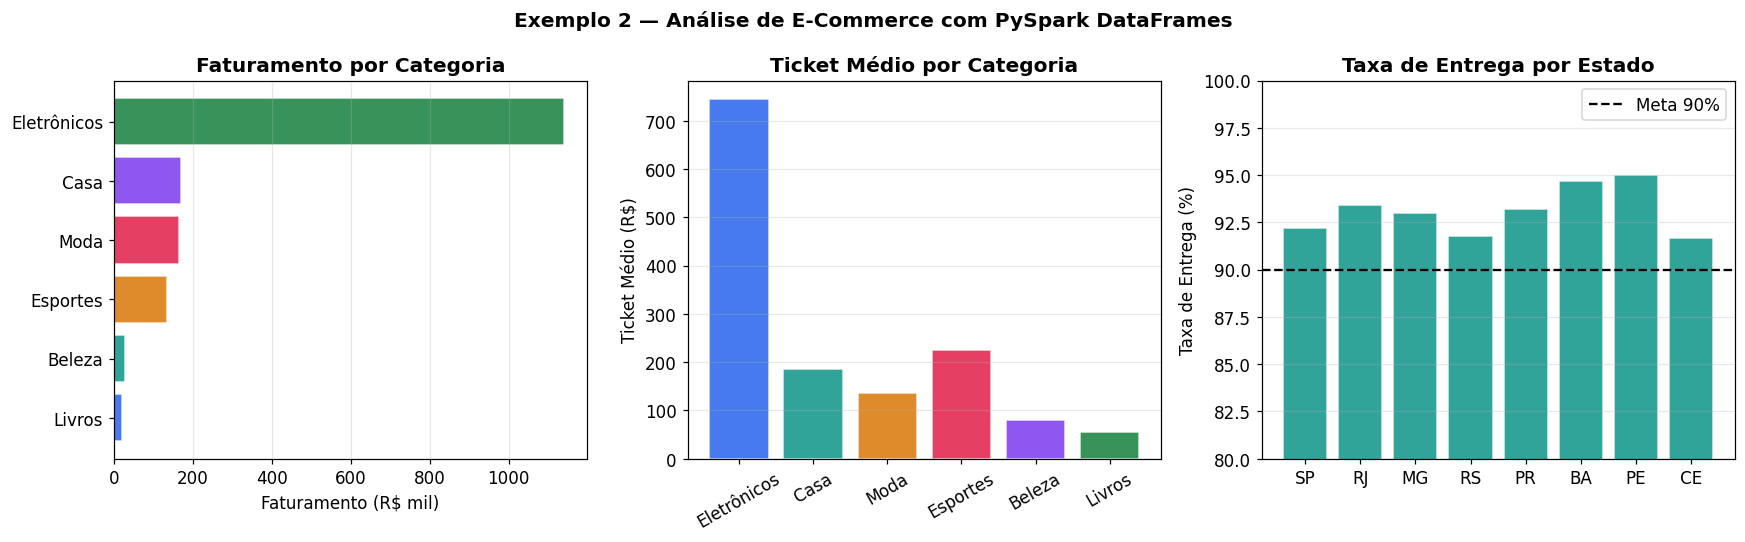

In [9]:
# ── Visualizações dos dados de e-commerce ─────────────────────────────────────
# Coletar para pandas para plotar (em produção, usaríamos BI tools)
fat_pd = faturamento_cat.toPandas()

taxa_pd = (
    df_ecom
    .groupBy('estado')
    .agg(F.count('pedido_id').alias('pedidos'),
         F.round(F.avg('entregue') * 100, 1).alias('taxa_entrega_pct'))
    .toPandas()
    .sort_values('pedidos', ascending=False)
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
cores_cat = ['#2563eb', '#0d9488', '#d97706', '#e11d48', '#7c3aed', '#15803d']

# Faturamento por categoria
axes[0].barh(fat_pd['categoria'][::-1], fat_pd['faturamento_total'][::-1] / 1000,
             color=cores_cat, alpha=.85, edgecolor='white')
axes[0].set_xlabel('Faturamento (R$ mil)')
axes[0].set_title('Faturamento por Categoria', fontweight='bold')
axes[0].grid(axis='x', alpha=.3)

# Ticket médio por categoria
axes[1].bar(fat_pd['categoria'], fat_pd['ticket_medio'],
            color=cores_cat, alpha=.85, edgecolor='white')
axes[1].set_ylabel('Ticket Médio (R$)')
axes[1].set_title('Ticket Médio por Categoria', fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(axis='y', alpha=.3)

# Taxa de entrega por estado
cores_taxa = ['#e11d48' if t < 90 else '#0d9488' for t in taxa_pd['taxa_entrega_pct']]
bars_taxa = axes[2].bar(taxa_pd['estado'], taxa_pd['taxa_entrega_pct'],
                         color=cores_taxa, alpha=.85, edgecolor='white')
axes[2].axhline(90, color='black', ls='--', lw=1.5, label='Meta 90%')
axes[2].set_ylabel('Taxa de Entrega (%)')
axes[2].set_title('Taxa de Entrega por Estado', fontweight='bold')
axes[2].set_ylim(80, 100)
axes[2].legend()
axes[2].grid(axis='y', alpha=.3)

plt.suptitle('Exemplo 2 — Análise de E-Commerce com PySpark DataFrames', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 3 · Exemplo 3 — PySpark MLlib: Pipeline de ML Escalável
### Problema: prever cancelamento de pedido (churn de compra)

**Variável alvo:** `cancelado` (1 = pedido cancelado, 0 = concluído)  
**Preditores:** valor do pedido, desconto, tempo de entrega esperado, histórico do cliente, categoria

---

### Spark MLlib vs scikit-learn: qual a diferença?

| Aspecto | scikit-learn | Spark MLlib |
|---|---|---|
| Escala | Single machine | Cluster distribuído |
| Dados | Cabe na RAM | Qualquer tamanho (TB/PB) |
| API | `.fit(X, y)` / `.predict(X)` | Pipeline com estágios |
| Features | numpy arrays | Vetores densos/esparsos |
| Paralelismo | Limitado (joblib) | Nativo e automático |

### O Pipeline do Spark MLlib

O `Pipeline` do Spark MLlib funciona de forma similar ao do scikit-learn:

```
StringIndexer  →  Converte categoria (string) em índice numérico
      ↓
VectorAssembler →  Combina todas as features em um único vetor
      ↓
StandardScaler  →  Padroniza o vetor de features (média 0, desvio 1)
      ↓
RandomForest   →  Treina o modelo de classificação
```

A diferença fundamental é que todo o pipeline **roda distribuído** — cada estágio processa os dados em paralelo nos workers do cluster.

In [10]:
# ── Dados de pedidos com flag de cancelamento ──────────────────────────────────
np.random.seed(99)
n3 = 3000

valor_pedido   = np.random.exponential(300, n3).clip(20, 5000)
desconto_p3    = np.random.choice([0, 5, 10, 15, 20, 30], n3, p=[0.35, 0.15, 0.2, 0.1, 0.12, 0.08])
prazo_entrega  = np.random.randint(1, 30, n3)  # dias
historico_comp = np.random.randint(0, 20, n3)  # compras anteriores
avaliacao_med  = np.random.uniform(1.0, 5.0, n3).round(1)
cat_p3         = np.random.choice(['Eletrônicos', 'Moda', 'Casa', 'Esportes', 'Livros'], n3,
                                   p=[0.3, 0.25, 0.2, 0.15, 0.1])

# Lógica de cancelamento
logit3 = (
    -2.0
    + 0.002 * valor_pedido      # pedidos caros são mais cancelados
    - 0.04  * desconto_p3        # desconto alto reduz cancelamento
    + 0.05  * prazo_entrega      # prazo longo aumenta cancelamento
    - 0.08  * historico_comp     # clientes frequentes cancelam menos
    - 0.4   * avaliacao_med      # boa avaliação histórica → menos cancelamento
)
prob3      = 1 / (1 + np.exp(-logit3))
cancelado  = (np.random.uniform(0, 1, n3) < prob3).astype(int)

df_cancel_pd = pd.DataFrame({
    'valor_pedido':   valor_pedido.round(2),
    'desconto_pct':   desconto_p3,
    'prazo_dias':     prazo_entrega,
    'historico_comp': historico_comp,
    'avaliacao_med':  avaliacao_med,
    'categoria':      cat_p3,
    'cancelado':      cancelado
})

df_cancel = spark.createDataFrame(df_cancel_pd)
print(f'Dataset: {df_cancel.count()} pedidos')
print(f'Taxa de cancelamento: {df_cancel_pd["cancelado"].mean():.1%}')
df_cancel.show(5)

Dataset: 3000 pedidos
Taxa de cancelamento: 7.9%
+------------+------------+----------+--------------+-------------+-----------+---------+
|valor_pedido|desconto_pct|prazo_dias|historico_comp|avaliacao_med|  categoria|cancelado|
+------------+------------+----------+--------------+-------------+-----------+---------+
|      334.68|           5|         1|            12|          1.2|Eletrônicos|        0|
|      200.88|           0|        18|            17|          4.3|     Livros|        0|
|      523.74|           5|         4|            14|          2.0|Eletrônicos|        0|
|        20.0|           0|         6|            19|          2.7|Eletrônicos|        0|
|      495.16|           0|        27|            16|          1.9|       Casa|        0|
+------------+------------+----------+--------------+-------------+-----------+---------+
only showing top 5 rows


In [11]:
# ── Pipeline MLlib: pré-processamento + modelo ─────────────────────────────────

# Dividir em treino e teste (estratificação não é nativa no Spark → usamos randomSplit)
df_treino, df_teste = df_cancel.randomSplit([0.8, 0.2], seed=42)
print(f'Treino: {df_treino.count()} | Teste: {df_teste.count()}')

# ESTÁGIO 1: Converter categoria (string) em índice numérico
indexer = StringIndexer(
    inputCol='categoria',
    outputCol='categoria_idx',
    handleInvalid='keep'
)

# ESTÁGIO 2: Montar o vetor de features (obrigatório no Spark MLlib)
features = ['valor_pedido', 'desconto_pct', 'prazo_dias',
            'historico_comp', 'avaliacao_med', 'categoria_idx']

assembler = VectorAssembler(
    inputCols=features,
    outputCol='features_raw'
)

# ESTÁGIO 3: Padronização (StandardScaler)
scaler_spark = SparkScaler(
    inputCol='features_raw',
    outputCol='features',
    withMean=True, withStd=True
)

# ESTÁGIO 4: Modelo Random Forest
rf_spark = SparkRF(
    featuresCol='features',
    labelCol='cancelado',
    numTrees=100,
    maxDepth=5,
    seed=42
)

# Montar o pipeline
pipeline_spark = SparkPipeline(stages=[indexer, assembler, scaler_spark, rf_spark])

# Treinar
print('\nTreinando o pipeline...')
t_start = time.time()
modelo_spark = pipeline_spark.fit(df_treino)
print(f'Tempo de treino: {time.time() - t_start:.2f}s')
print('Pipeline treinado!')

Treino: 2410 | Teste: 590

Treinando o pipeline...
Tempo de treino: 65.16s
Pipeline treinado!


=== Métricas no conjunto de teste ===
  AUC:      0.7088
  F1-Score: 0.9169
  Acurácia: 0.9390


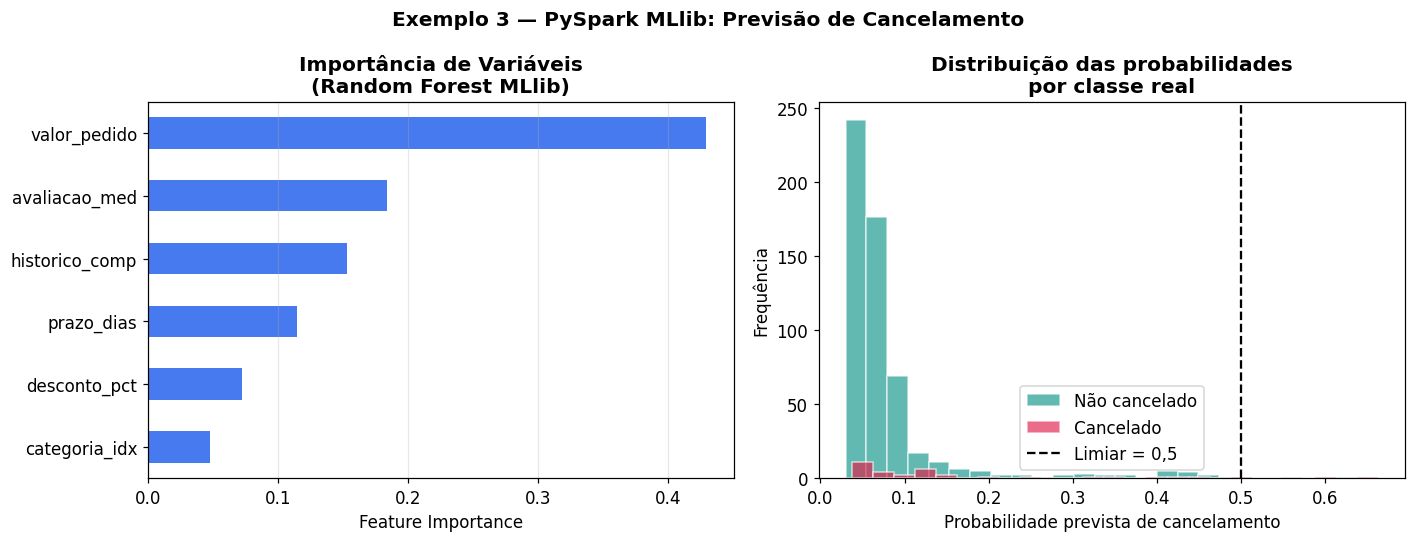


Variável mais importante: valor_pedido


In [12]:
# ── Avaliação do modelo no conjunto de teste ───────────────────────────────────
previsoes = modelo_spark.transform(df_teste)

# Avaliadores
avaliador_auc  = BinaryClassificationEvaluator(
    labelCol='cancelado', rawPredictionCol='rawPrediction',
    metricName='areaUnderROC'
)
avaliador_f1   = MulticlassClassificationEvaluator(
    labelCol='cancelado', predictionCol='prediction',
    metricName='f1'
)
avaliador_acc  = MulticlassClassificationEvaluator(
    labelCol='cancelado', predictionCol='prediction',
    metricName='accuracy'
)

auc = avaliador_auc.evaluate(previsoes)
f1  = avaliador_f1.evaluate(previsoes)
acc = avaliador_acc.evaluate(previsoes)

print('=== Métricas no conjunto de teste ===')
print(f'  AUC:      {auc:.4f}')
print(f'  F1-Score: {f1:.4f}')
print(f'  Acurácia: {acc:.4f}')

# Importância de variáveis
rf_model = modelo_spark.stages[-1]  # último estágio = RandomForest
importancias_spark = pd.Series(
    rf_model.featureImportances.toArray(),
    index=features
).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Importância de variáveis
importancias_spark.plot(kind='barh', ax=axes[0], color='#2563eb', alpha=.85)
axes[0].set_title('Importância de Variáveis\n(Random Forest MLlib)', fontweight='bold')
axes[0].set_xlabel('Feature Importance')
axes[0].grid(axis='x', alpha=.3)

# Distribuição das probabilidades de cancelamento
prob_pd = previsoes.select('cancelado', 'probability').toPandas()
prob_pd['prob_cancel'] = prob_pd['probability'].apply(lambda x: float(x[1]))

for cls, cor, label in [(0, '#0d9488', 'Não cancelado'), (1, '#e11d48', 'Cancelado')]:
    mask = prob_pd['cancelado'] == cls
    axes[1].hist(prob_pd[mask]['prob_cancel'], bins=25, alpha=0.65,
                 color=cor, label=label, edgecolor='white')
axes[1].axvline(0.5, color='black', ls='--', lw=1.5, label='Limiar = 0,5')
axes[1].set_xlabel('Probabilidade prevista de cancelamento')
axes[1].set_ylabel('Frequência')
axes[1].set_title('Distribuição das probabilidades\npor classe real', fontweight='bold')
axes[1].legend()

plt.suptitle('Exemplo 3 — PySpark MLlib: Previsão de Cancelamento', fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nVariável mais importante: {importancias_spark.idxmax()}')

---
## 4 · Exemplo 4 — Particionamento, Cache e DAG
### Entendendo como o Spark executa o código

---

### Lazy Evaluation: o Spark é preguiçoso (de propósito)

Uma das características mais importantes do Spark é a **avaliação preguiçosa (lazy evaluation)**:

```python
df2 = df.filter(df.valor > 100)   # NÃO executa — apenas registra a transformação
df3 = df2.groupBy('cat').count()  # NÃO executa — adiciona ao plano
df3.show()                         # EXECUTA tudo agora — esta é uma "action"
```

**Por que isso é importante?** O Spark pode otimizar o plano inteiro antes de executar:
- Reordenar filtros para processar menos dados
- Eliminar colunas desnecessárias cedo
- Combinar múltiplas operações em um único passo

### Transformações vs Actions

| Tipo | O que faz | Exemplos |
|---|---|---|
| **Transformação** (lazy) | Registra no DAG, não executa | `filter`, `select`, `groupBy`, `join`, `map` |
| **Action** (eager) | Materializa o resultado, executa tudo | `show`, `count`, `collect`, `save`, `take` |

### DAG: o grafo da execução

O Spark representa o plano de execução como um **DAG (Directed Acyclic Graph)** — um grafo dirigido sem ciclos onde cada nó é uma transformação e as arestas indicam dependências:

```
parallelize() → flatMap() → reduceByKey() → sortBy() → take(15)
       ↑ Stage 1 ──────────────────────────────────────────┘
                           ↑ Shuffle boundary ↑
```

### Cache e Persist

Quando um DataFrame é usado mais de uma vez, convém **armazená-lo em memória** para não recalculá-lo:

```python
df.cache()            # armazena em memória (padrão)
df.persist()          # igual ao cache()
df.unpersist()        # libera a memória
```

> **Quando usar cache:** quando o mesmo DataFrame é referenciado em múltiplas actions (ex.: métricas diferentes, múltiplos gráficos). Sem cache, o Spark recalcula tudo desde o início para cada action.

In [13]:
# ── Demonstração de particionamento ───────────────────────────────────────────
import time

print('=== Particionamento ===')
print(f'Partições atuais do df_ecom: {df_ecom.rdd.getNumPartitions()}')

# Repartition: redistribui TODOS os dados (full shuffle — caro!)
df_8p = df_ecom.repartition(8)
print(f'Após repartition(8):  {df_8p.rdd.getNumPartitions()} partições')

# Coalesce: REDUZ partições sem full shuffle (mais eficiente para reduzir)
df_2p = df_ecom.coalesce(2)
print(f'Após coalesce(2):     {df_2p.rdd.getNumPartitions()} partições')

print('\n=== Cache vs Sem Cache ===')

# Sem cache: cada action recalcula do início
df_sem_cache = df_ecom.filter(F.col('valor_bruto') > 200)

t0 = time.time()
c1 = df_sem_cache.count()
t_sem1 = time.time() - t0

t0 = time.time()
c2 = df_sem_cache.agg(F.avg('valor_bruto')).collect()
t_sem2 = time.time() - t0

# Com cache: calcula uma vez, reutiliza
df_com_cache = df_ecom.filter(F.col('valor_bruto') > 200).cache()
df_com_cache.count()  # materializa o cache

t0 = time.time()
c3 = df_com_cache.count()
t_com1 = time.time() - t0

t0 = time.time()
c4 = df_com_cache.agg(F.avg('valor_bruto')).collect()
t_com2 = time.time() - t0

print(f'\nSem cache — 1ª action (count):  {t_sem1*1000:.0f} ms')
print(f'Sem cache — 2ª action (avg):    {t_sem2*1000:.0f} ms')
print(f'Com cache — 1ª action (count):  {t_com1*1000:.0f} ms (já em memória)')
print(f'Com cache — 2ª action (avg):    {t_com2*1000:.0f} ms (já em memória)')

df_com_cache.unpersist()  # libera a memória

=== Particionamento ===
Partições atuais do df_ecom: 12
Após repartition(8):  8 partições
Após coalesce(2):     2 partições

=== Cache vs Sem Cache ===

Sem cache — 1ª action (count):  106 ms
Sem cache — 2ª action (avg):    128 ms
Com cache — 1ª action (count):  88 ms (já em memória)
Com cache — 2ª action (avg):    95 ms (já em memória)


DataFrame[pedido_id: bigint, cliente_id: bigint, categoria: string, valor_bruto: double, desconto_pct: bigint, valor_liquido: double, estado: string, data_pedido: string, entregue: bigint]

In [14]:
# ── explain(): ver o plano de execução (DAG) ───────────────────────────────────

query_complexa = (
    df_ecom
    .filter(F.col('valor_bruto') > 100)
    .filter(F.col('entregue') == 1)
    .groupBy('categoria', 'estado')
    .agg(
        F.count('pedido_id').alias('n_pedidos'),
        F.sum('valor_liquido').alias('faturamento')
    )
    .filter(F.col('n_pedidos') > 10)
    .orderBy('faturamento', ascending=False)
)

print('=== Plano de execução (explain) ===')
print('O Catalyst Optimizer combina os dois filtros em uma única passagem:')
query_complexa.explain()

print('\n=== Resultado final ===')
query_complexa.show(10)

=== Plano de execução (explain) ===
O Catalyst Optimizer combina os dois filtros em uma única passagem:
== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Sort [faturamento#5290 DESC NULLS LAST], true, 0
   +- Exchange rangepartitioning(faturamento#5290 DESC NULLS LAST, 4), ENSURE_REQUIREMENTS, [plan_id=1665]
      +- Filter (n_pedidos#5289L > 10)
         +- HashAggregate(keys=[categoria#10, estado#14], functions=[count(pedido_id#8L), sum(valor_liquido#13)])
            +- Exchange hashpartitioning(categoria#10, estado#14, 4), ENSURE_REQUIREMENTS, [plan_id=1661]
               +- HashAggregate(keys=[categoria#10, estado#14], functions=[partial_count(pedido_id#8L), partial_sum(valor_liquido#13)])
                  +- Project [pedido_id#8L, categoria#10, valor_liquido#13, estado#14]
                     +- Filter (((isnotnull(valor_bruto#11) AND isnotnull(entregue#16L)) AND (valor_bruto#11 > 100.0)) AND (entregue#16L = 1))
                        +- InMemoryTableScan [categoria#

In [15]:
# ── Resumo da arquitetura Spark (texto) ───────────────────────────────────────
print('=== Arquitetura Apache Spark ===')
print()
print('  [ Driver (SparkContext) ]')
print('          |')
print('          |  submete jobs')
print('          v')
print('  [ Cluster Manager (YARN / Kubernetes / local[*]) ]')
print('     /           |           \\')
print('    v             v             v')
print('[ Worker 1 ]  [ Worker 2 ]  [ Worker 3 ]')
print('  Executor        Executor        Executor')
print('  + Cache         + Cache         + Cache')
print('  + Particao 1    + Particao 2    + Particao 3')
print()
print('  <---- Shuffle: redistribuicao de dados entre workers ---->') 
print()
print('Em modo local (local[*]): Driver e Workers rodam no mesmo processo.')
print('Em cluster real (AWS EMR, Databricks, etc.): cada caixa e uma maquina diferente.')

=== Arquitetura Apache Spark ===

  [ Driver (SparkContext) ]
          |
          |  submete jobs
          v
  [ Cluster Manager (YARN / Kubernetes / local[*]) ]
     /           |           \
    v             v             v
[ Worker 1 ]  [ Worker 2 ]  [ Worker 3 ]
  Executor        Executor        Executor
  + Cache         + Cache         + Cache
  + Particao 1    + Particao 2    + Particao 3

  <---- Shuffle: redistribuicao de dados entre workers ---->

Em modo local (local[*]): Driver e Workers rodam no mesmo processo.
Em cluster real (AWS EMR, Databricks, etc.): cada caixa e uma maquina diferente.


---
## 5 · EXERCÍCIO — Sua Vez!

### Contexto
Uma rede de supermercados com lojas em todo o Brasil quer analisar seus dados de vendas
e construir um modelo para prever promoções que podem resultar em **prejuízo** (venda abaixo do custo).

| Variável | Descrição |
|----------|----------|
| `produto_id` | Código do produto |
| `categoria` | Categoria do produto |
| `preco_venda` | Preço de venda (R$) |
| `custo_unitario` | Custo de compra do produto (R$) |
| `quantidade` | Unidades vendidas |
| `desconto_pct` | Desconto aplicado (%) |
| `regiao` | Região da loja |
| `dia_semana` | Dia da semana (0=Segunda, 6=Domingo) |
| `prejuizo` | **Alvo:** 1 = venda resultou em prejuízo (preço < custo após desconto) |

### Tarefas de Análise com DataFrames

1. **Explore os dados** com `describe()`, `groupBy` e Spark SQL
   - Calcule a margem média por categoria (`preco_venda - custo_unitario`)
   - Identifique qual região tem mais vendas com prejuízo

2. **Análise de produtos** com Spark SQL
   - Encontre as 10 categorias com maior taxa de prejuízo
   - Calcule o faturamento total e lucro/prejuízo por região

### Tarefas de Machine Learning com MLlib

3. **Construa um Pipeline MLlib** para prever `prejuizo`
   - Use `StringIndexer` para `categoria` e `regiao`
   - Use `VectorAssembler` com todas as features numéricas
   - Treine um `RandomForestClassifier` do Spark

4. **Avalie o modelo** usando `BinaryClassificationEvaluator` (AUC)
   - Qual variável mais impacta a previsão de prejuízo?

5. **Performance:** aplique `.cache()` no DataFrame de treino e compare o tempo
   com e sem cache para uma operação repetida (ex.: `count()` 3 vezes).

> **Dica para T3:** a sequência de estágios é: StringIndexer (categoria) → StringIndexer (regiao) → VectorAssembler → RandomForestClassifier.

In [16]:
# ── Dados do exercício (não altere esta célula) ────────────────────────────────
np.random.seed(77)
n_ex = 4000

categorias_ex = ['Hortifrúti', 'Carnes', 'Laticínios', 'Bebidas', 'Limpeza', 'Padaria', 'Congelados']
regioes_ex    = ['Norte', 'Nordeste', 'Centro-Oeste', 'Sudeste', 'Sul']

cat_ex     = np.random.choice(categorias_ex, n_ex, p=[0.2, 0.18, 0.15, 0.15, 0.12, 0.12, 0.08])
regiao_ex  = np.random.choice(regioes_ex, n_ex, p=[0.1, 0.25, 0.15, 0.35, 0.15])

custo_medio = {'Hortifrúti': 3.0, 'Carnes': 25.0, 'Laticínios': 6.0, 'Bebidas': 4.5,
               'Limpeza': 8.0, 'Padaria': 2.5, 'Congelados': 12.0}

custo_ex     = np.array([max(0.5, np.random.normal(custo_medio[c], custo_medio[c]*0.3))
                          for c in cat_ex]).round(2)
margem_markup = np.random.uniform(0.10, 0.60, n_ex)
preco_ex     = (custo_ex * (1 + margem_markup)).round(2)
desconto_ex  = np.random.choice([0, 5, 10, 15, 20, 25, 30, 40], n_ex,
                                  p=[0.3, 0.15, 0.2, 0.1, 0.1, 0.05, 0.05, 0.05])
qtde_ex      = np.random.randint(1, 50, n_ex)
dia_semana   = np.random.randint(0, 7, n_ex)

preco_final  = preco_ex * (1 - desconto_ex / 100)
prejuizo_ex  = (preco_final < custo_ex).astype(int)

df_super_pd = pd.DataFrame({
    'produto_id':      range(1, n_ex + 1),
    'categoria':       cat_ex,
    'preco_venda':     preco_ex,
    'custo_unitario':  custo_ex,
    'quantidade':      qtde_ex,
    'desconto_pct':    desconto_ex,
    'regiao':          regiao_ex,
    'dia_semana':      dia_semana,
    'prejuizo':        prejuizo_ex
})

df_super = spark.createDataFrame(df_super_pd)
df_super.createOrReplaceTempView('vendas')

print('Dados do exercício:')
df_super.show(8)
print(f'Total de registros: {df_super.count():,}')
print(f'Taxa de prejuízo: {df_super_pd["prejuizo"].mean():.1%}')

Dados do exercício:
+----------+----------+-----------+--------------+----------+------------+------------+----------+--------+
|produto_id| categoria|preco_venda|custo_unitario|quantidade|desconto_pct|      regiao|dia_semana|prejuizo|
+----------+----------+-----------+--------------+----------+------------+------------+----------+--------+
|         1|   Padaria|       4.54|          3.05|         1|           0|    Nordeste|         0|       0|
|         2|   Bebidas|      10.15|          7.21|         2|           0|     Sudeste|         3|       0|
|         3|   Limpeza|       8.27|          6.58|        39|           5|    Nordeste|         5|       0|
|         4|Hortifrúti|       4.45|           3.0|        20|          40|    Nordeste|         4|       1|
|         5|Hortifrúti|        3.8|          3.16|        31|          40|     Sudeste|         6|       1|
|         6|   Limpeza|      15.14|          9.92|        12|           5|    Nordeste|         6|       0|
|       

In [17]:
# ── TAREFA 1: Exploração dos dados ────────────────────────────────────────────
# Dica: use .describe(), groupBy e Spark SQL

# Seu código aqui:


In [18]:
# ── TAREFA 2: Análise com Spark SQL ───────────────────────────────────────────
# Encontre as categorias com maior taxa de prejuízo
# Calcule faturamento e resultado por região

# Seu código aqui:


In [19]:
# ── TAREFA 3: Pipeline MLlib para prever prejuizo ─────────────────────────────
# Sequência: StringIndexer (categoria) → StringIndexer (regiao)
#            → VectorAssembler → RandomForestClassifier
# Features numéricas: preco_venda, custo_unitario, quantidade, desconto_pct, dia_semana

df_treino_ex, df_teste_ex = df_super.randomSplit([0.8, 0.2], seed=42)
print(f'Treino: {df_treino_ex.count()} | Teste: {df_teste_ex.count()}')

# Seu código aqui:


Treino: 3203 | Teste: 797


In [20]:
# ── TAREFA 4: Avaliação do modelo ─────────────────────────────────────────────
# Use BinaryClassificationEvaluator para calcular AUC
# Plote a importância de variáveis

# Seu código aqui:


In [21]:
# ── TAREFA 5: Demonstração de cache ───────────────────────────────────────────
# Compare o tempo de 3 operações count() com e sem cache

# Seu código aqui:


---
### Perguntas para reflexão

Responda nas células abaixo (texto livre — clique duas vezes para editar):

**1.** Em que situação faria sentido usar PySpark ao invés de pandas para este dataset de supermercado?

> *Sua resposta aqui...*

**2.** Por que o `StringIndexer` é necessário antes do `VectorAssembler`? O que aconteceria se pulássemos esse passo?

> *Sua resposta aqui...*

**3.** O que é "lazy evaluation" e qual a sua principal vantagem no Spark?

> *Sua resposta aqui...*

**4.** A variável mais importante para prever prejuízo foi a esperada? Por quê?

> *Sua resposta aqui...*

**5.** Em um cenário real com 10 TB de dados de supermercado, qual seria a diferença entre usar pandas e usar PySpark? Que problemas o pandas teria?

> *Sua resposta aqui...*

In [22]:
# ── Encerrar a SparkSession (sempre faça isso ao terminar!) ───────────────────
# spark.stop()
# print('SparkSession encerrada.')
print('Notebook concluído! Descomente spark.stop() quando terminar.')

Notebook concluído! Descomente spark.stop() quando terminar.


---
**Ciência de Dados · Aula 12 · Prof. Mesc. Diego Ramos Inácio · Univassouras · 2026**